<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-5-Thermodynamics/Untitled170.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Controlled Variational Problem**

Given two states $x_0 = (P_0, V_0, T_0, U_0, S_0)$ and $x_1 = (P_1, V_1, T_1, U_1, S_1)\in \mathbb{R}^5$, find a quasistatic process

$$
c(s) = \big(P(s), V(s), T(s), U(s), S(s)\big),
$$

such that $c(0)=x_0$ and $c(1)=x_1$, which minimizes the energy functional
$$E(c)=\frac{1}{2}\int_0^1 (\dot S(s)^2 + \dot V(s)^2 + \dot T(s)^2 + \dot P(s)^2) ds.$$



This problem can be modeled by a Lagrangian $L:T\mathbb{R}^5 \to \mathbb{R}$ with a nonholonomic constraint,

$$
L = \frac{1}{2}\big(\dot S(s)^2 + \dot V(s)^2 + \dot T(s)^2 + \dot P(s)^2\big)
+ \lambda\big(\dot U - T\,\dot S + P\,\dot V\big),
$$

where $\lambda$ is a Lagrange multiplier enforcing the Gibbs constraint.

/tmp/ipykernel_1993/3521964722.py:124: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss_hist.append(float(loss.numpy()))


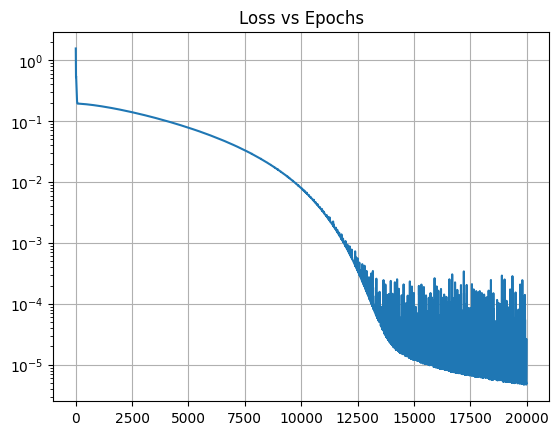

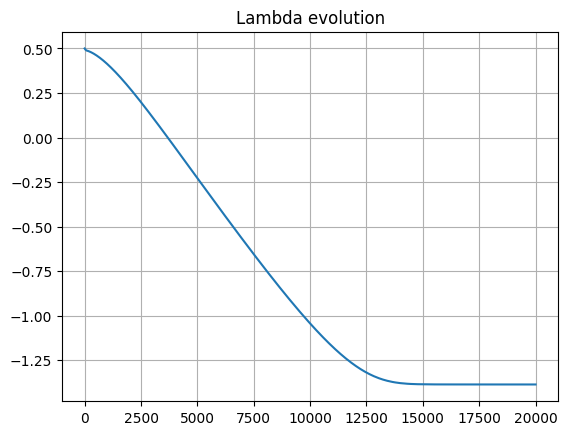

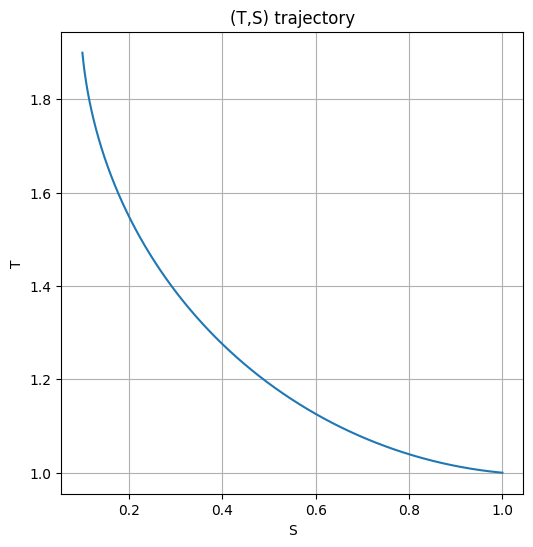

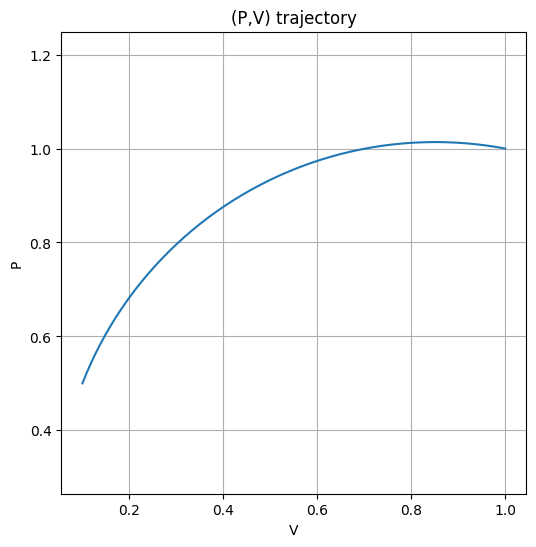

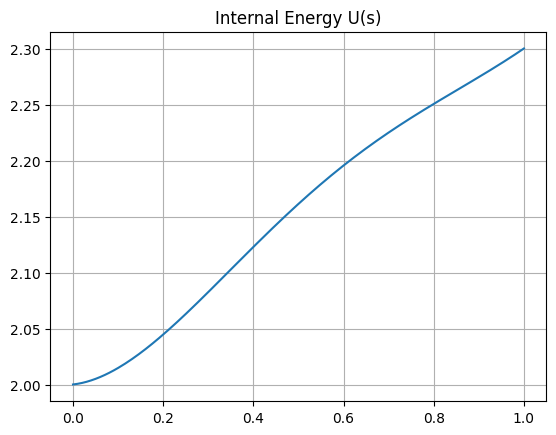

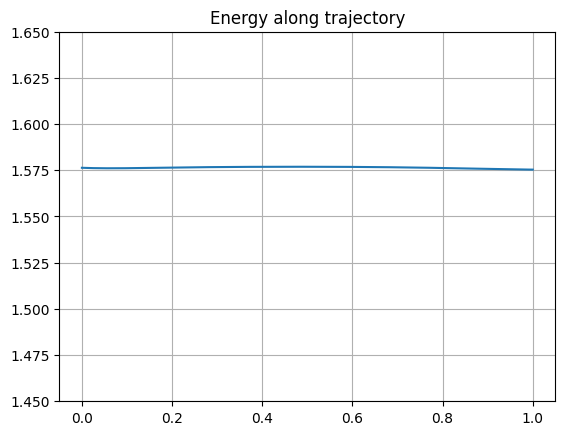

In [ ]:
# ==========================================
# 1. Imports
# ==========================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================
# 2. Boundary data
# ==========================================


P0, V0, T0, U0, S0 = 0.5, 0.1, 1.9, 2.0, 0.1
P1, V1, T1, U1, S1 = 1.0, 1.0, 1.0, 2.3, 1.0

# ==========================================
# 3. Trainable lambda
# ==========================================
lam = tf.Variable(0.5, trainable=True, dtype=tf.float32)

# ==========================================
# 4. Neural network
# ==========================================
net = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(164, activation='tanh'),
    tf.keras.layers.Dense(164, activation='tanh'),
    tf.keras.layers.Dense(4)  # outputs: P, V, T, S corrections
])

optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)

# ==========================================
# 5. Hard embedding
# ==========================================
def model(s):
    out = net(s)

    p_nn = out[:, 0:1]
    v_nn = out[:, 1:2]
    t_nn = out[:, 2:3]
    s_nn = out[:, 3:4]

    P = (1-s)*P0 + s*P1 + s*(1-s)*p_nn
    V = (1-s)*V0 + s*V1 + s*(1-s)*v_nn
    T = (1-s)*T0 + s*T1 + s*(1-s)*t_nn
    S = (1-s)*S0 + s*S1 + s*(1-s)*s_nn

    return P, V, T, S

# ==========================================
# 6. Training step
# ==========================================
@tf.function
def train_step(s):

    s = tf.reshape(s, (-1,1))

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(s)

        P, V, T, S = model(s)

        dP = tape.gradient(P, s)
        dV = tape.gradient(V, s)
        dT = tape.gradient(T, s)
        dS = tape.gradient(S, s)

        d2P = tape.gradient(dP, s)
        d2V = tape.gradient(dV, s)
        d2T = tape.gradient(dT, s)
        d2S = tape.gradient(dS, s)

        # ==================================
        # Euler-Lagrange residuals
        # ==================================
        res_TS1 = d2T + lam * dS
        res_TS2 = d2S - lam * dT

        res_PV1 = d2P - lam * dV
        res_PV2 = d2V + lam * dP

        loss_EL = tf.reduce_mean(res_TS1**2 + res_TS2**2 +
                                 res_PV1**2 + res_PV2**2)

        # ==================================
        # Energy regularization
        # ==================================
        E = 0.5*(dS**2 + dT**2 + dV**2 + dP**2)
        loss_energy = tf.reduce_mean((E - tf.reduce_mean(E))**2)

        # ==================================
        # Compute U via constraint
        # ==================================
        ds = s[1] - s[0]
        integrand = T*dS - P*dV
        U = U0 + tf.cumsum(integrand, axis=0) * ds

        loss_U = (U[-1] - U1)**2

        # ==================================
        # Total loss
        # ==================================
        loss = loss_EL + 0.5*loss_energy + loss_U

    vars = net.trainable_variables + [lam]
    grads = tape.gradient(loss, vars)
    optimizer.apply_gradients(zip(grads, vars))

    return loss, U, E

# ==========================================
# 7. Training
# ==========================================
epochs = 20000
s_train = tf.linspace(0.0, 1.0, 200)

loss_hist = []
lambda_hist = []

for ep in range(epochs):
    loss, U_tmp, E_tmp = train_step(s_train)

    loss_hist.append(float(loss.numpy()))
    lambda_hist.append(float(lam.numpy()))

# ==========================================
# 8. Evaluation
# ==========================================
s = tf.reshape(tf.linspace(0.0,1.0,200), (-1,1))

with tf.GradientTape(persistent=True) as tape:
    tape.watch(s)
    P, V, T, S = model(s)

dP = tape.gradient(P, s)
dV = tape.gradient(V, s)
dT = tape.gradient(T, s)
dS = tape.gradient(S, s)

E = 0.5*(dS**2 + dT**2 + dV**2 + dP**2)

ds = s[1] - s[0]
U = U0 + tf.cumsum(T*dS - P*dV, axis=0)*ds

# Convert to numpy
P = P.numpy().flatten()
V = V.numpy().flatten()
T = T.numpy().flatten()
S = S.numpy().flatten()
U = U.numpy().flatten()
E = E.numpy().flatten()
s = s.numpy().flatten()

# ==========================================
# 9. Plots
# ==========================================

# Loss
plt.figure()
plt.plot(loss_hist)
plt.yscale('log')
plt.title("Loss vs Epochs")
plt.grid()
plt.show()

# Lambda
plt.figure()
plt.plot(lambda_hist)
plt.title("Lambda evolution")
plt.grid()
plt.show()

# (T,S)
plt.figure(figsize=(6,6))  # square figure
plt.plot(S, T)
plt.xlabel("S")
plt.ylabel("T")
plt.title("(T,S) trajectory")
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# (P,V)
plt.figure(figsize=(6,6))  # square figure
plt.axis('equal')
plt.plot(V, P)
plt.xlabel("V")
plt.ylabel("P")
plt.title("(P,V) trajectory")
plt.grid()
#plt.gca().set_aspect('equal', adjustable='box')
plt.show()



# U(s)
plt.figure()
plt.plot(s, U)
plt.title("Internal Energy U(s)")
plt.grid()
plt.show()

# Energy
plt.figure()
plt.plot(s, E)
plt.title("Energy along trajectory")
plt.grid()
plt.ylim(1.45, 1.65)
plt.show()